# Practical Session: Air-Sea Interaction & Turbulent Heat Fluxes (COARE 3.5)

## 1. Theoretical Background & Principal Equations

In oceanographic and meteorological studies, the **COARE (Coupled Ocean-Atmosphere Response Experiment)** algorithm estimates turbulent surface fluxes of momentum, sensible heat, and latent heat based on bulk meteorological observations.

### Key Governing Equations in COARE 3.5

#### 1. Sensible Heat Flux ($H$)
Sensible heat flux represents the direct heat transfer between the ocean surface and the atmosphere driven by temperature differences:
$$H = \rho_a c_p C_h u_* (T_s - T_a) = \rho_a c_p c_h U (T_s - T_a)$$

Where:
- $\rho_a$: Air density ($kg/m^3$)
- $c_p$: Specific heat capacity of air ($J/(kg \cdot K)$)
- $C_h, c_h$: Exchange / bulk transfer coefficients for sensible heat
- $u_*$: Friction velocity ($m/s$)
- $T_s$: Sea surface temperature ($SST$)
- $T_a$: Near-surface air temperature ($T_{air}$)
- $U$: Relative wind speed at reference height ($m/s$)

#### 2. Latent Heat Flux ($LE$)
Latent heat flux represents heat exchange associated with phase changes of water (evaporation or condensation):
$$LE = \rho_a L_v C_e u_* (q_s - q_a) = \rho_a L_v c_e U (q_s - q_a)$$

Where:
- $L_v$: Latent heat of vaporization ($J/kg$)
- $C_e, c_e$: Exchange / bulk transfer coefficients for evaporation
- $q_s$: Specific humidity at the sea surface ($kg/kg$)
- $q_a$: Specific humidity of air ($kg/kg$)

---

## 2. Library Imports
Import essential libraries for data manipulation, mathematical operations, data visualization, and the COARE 3.5 flux calculation package.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from coare35vn import coare35vn

## 3. Data Ingestion & Preprocessing
Load buoy meteorological data, parse the time index, and prepare inputs for the flux model.

In [2]:
filename = "data/AP/buoy/data_bouy.csv"

df_bouy = pd.read_csv(filename, sep='\t')
df_bouy['datetime'] = pd.to_datetime(df_bouy['datetime'])
df_bouy = df_bouy.set_index('datetime')

df_bouy

,ws,tair,rh,press,SUp,sst
datetime,,,,,,
2024-12-06 00:00:00,9.151888,-0.9,64.6,1013.4,529.9,-0.081400
2024-12-06 01:00:00,8.272195,-0.9,67.8,1013.3,401.2,-0.079937
2024-12-06 02:00:00,7.022106,-0.9,70.8,1013.6,87.7,-0.072550
2024-12-06 03:00:00,4.208119,-0.7,71.2,1013.8,0.0,-0.085164
2024-12-06 04:00:00,9.049000,-0.6,68.0,1013.6,0.0,-0.081067
...,...,...,...,...,...,...
2024-12-13 19:00:00,5.977793,2.0,83.2,993.5,0.0,0.711133
2024-12-13 20:00:00,5.519941,1.9,84.5,994.0,0.0,0.726267
2024-12-13 21:00:00,6.610554,2.2,79.4,994.2,7.1,0.729700


## 4. Computation of COARE 3.5 Turbulent Heat Fluxes
We run the COARE 3.5 algorithm with the following parameters:
- **Sensor Heights**: Wind speed (`zu`), air temperature (`zt`), and relative humidity (`zq`) are fixed at $1.8\text{ m}$.
- **Location Latitude**: $-62.109^{\circ}$ (Sub-Antarctic/Antarctic domain).
- **Boundary Layer Depth (`zi`)**: Set to $300\text{ m}$.
- **Cool-skin Model (`jcool`)**: Active (`1`).

In [3]:
# Compute turbulent fluxes using COARE 3.5 algorithm
A = coare35vn(
    df_bouy['ws'].values,
    df_bouy['tair'].values,
    df_bouy['rh'].values,
    df_bouy['sst'].values,
    P=df_bouy['press'].values,
    Rs=df_bouy['SUp'].values,
    Rl=288,
    zu=1.8,
    zt=1.8,
    zq=1.8,
    lat=-62.109,
    zi=300,
    rain=np.zeros_like(df_bouy['ws']),
    jcool=1
)

/home/lacrio/cryoextremes-practicals/meteo.py:157: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


## 5. Post-Processing & Filtering Extremes
Extract Sensible Heat Flux ($H$) and Latent Heat Flux ($LE$) from matrix $A$, filtering unrealistic outliers.

In [4]:
# Extract Sensible Heat Flux (H) and Latent Heat Flux (LE) with threshold filtering
df_bouy['H'] = np.where(np.abs(A[:, 2]) > 150, np.nan, A[:, 2])
df_bouy['LE'] = np.where(np.abs(A[:, 3]) > 150, np.nan, A[:, 3])

## 6. Time Window Selection
Slice the dataset to focus on the period from December 06 to December 12, 2024.

In [5]:
df_bouy = df_bouy.loc['2024-12-06':'2024-12-12']
df_bouy

,ws,tair,rh,press,SUp,sst,H,LE
datetime,,,,,,,,
2024-12-06 00:00:00,9.151888,-0.9,64.6,1013.4,529.90,-0.081400,13.362849,62.540917
2024-12-06 01:00:00,8.272195,-0.9,67.8,1013.3,401.20,-0.079937,11.982911,51.421519
2024-12-06 02:00:00,7.022106,-0.9,70.8,1013.6,87.70,-0.072550,10.135087,39.779440
2024-12-06 03:00:00,4.208119,-0.7,71.2,1013.8,0.00,-0.085164,4.196244,23.072508
2024-12-06 04:00:00,9.049000,-0.6,68.0,1013.6,0.00,-0.081067,7.897445,53.875356
...,...,...,...,...,...,...,...,...
2024-12-12 18:00:00,8.549993,2.9,90.3,990.7,176.50,0.666350,-35.571807,-12.611023
2024-12-12 19:00:00,9.810371,2.8,91.4,990.1,325.90,0.625117,-40.622898,-16.340625
2024-12-12 20:00:00,7.660012,3.2,91.0,989.9,265.20,0.689950,-35.011776,-15.188750


## 7. Hourly Reindexing & Regularization
Reindex the dataframe along a complete 1-hour temporal grid to fill gaps with explicit `NaN`s and export the processed file.

In [6]:
# Ensure DatetimeIndex and create full hourly time series
df_bouy.index = pd.to_datetime(df_bouy.index)
full_time_range = pd.date_range(
    start=df_bouy.index.min(), end=df_bouy.index.max(), freq="1h"
)

df_bouy = df_bouy.reindex(full_time_range)
df_bouy.index.name = "datetime"

# Export processed dataset
df_bouy.to_csv('data/pross/data_buoy_full_time.csv', sep='\t')
df_bouy

,ws,tair,rh,press,SUp,sst,H,LE
datetime,,,,,,,,
2024-12-06 00:00:00,9.151888,-0.9,64.6,1013.4,529.90,-0.081400,13.362849,62.540917
2024-12-06 01:00:00,8.272195,-0.9,67.8,1013.3,401.20,-0.079937,11.982911,51.421519
2024-12-06 02:00:00,7.022106,-0.9,70.8,1013.6,87.70,-0.072550,10.135087,39.779440
2024-12-06 03:00:00,4.208119,-0.7,71.2,1013.8,0.00,-0.085164,4.196244,23.072508
2024-12-06 04:00:00,9.049000,-0.6,68.0,1013.6,0.00,-0.081067,7.897445,53.875356
...,...,...,...,...,...,...,...,...
2024-12-12 19:00:00,9.810371,2.8,91.4,990.1,325.90,0.625117,-40.622898,-16.340625
2024-12-12 20:00:00,7.660012,3.2,91.0,989.9,265.20,0.689950,-35.011776,-15.188750
2024-12-12 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Multi-Parameter Visualization
Plot the time series of all meteorological variables alongside computed turbulent heat fluxes ($H$ & $LE$).

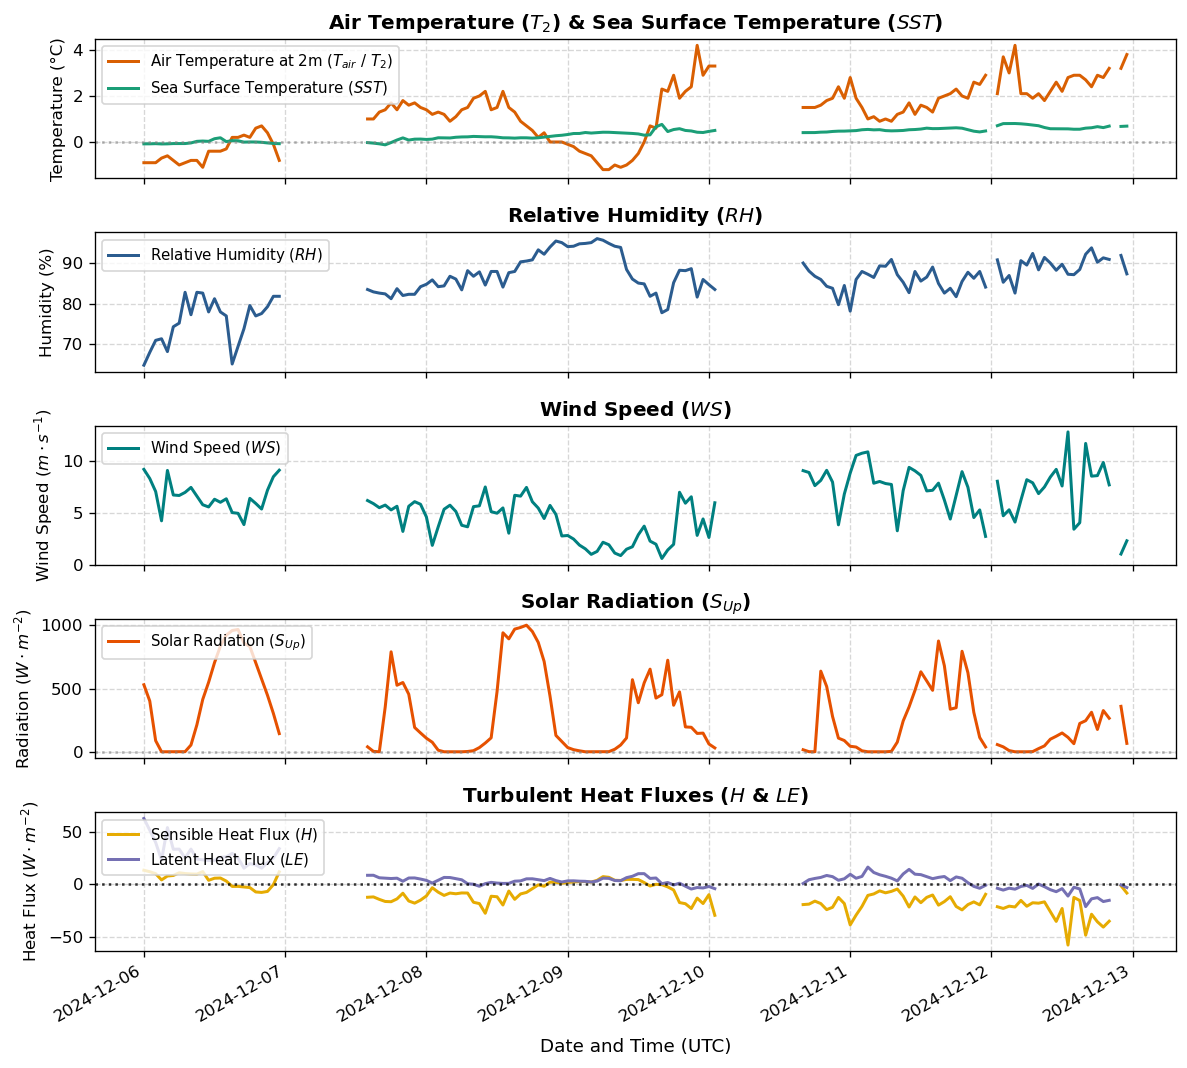

In [7]:
df_plot = df_bouy.copy()

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(10, 9), sharex=True, dpi=120
)

# --- SUBPLOT 1: Temperatures ---
ax1.plot(
    df_plot.index,
    df_plot['tair'],
    label='Air Temperature at 2m ($T_{air}$ / $T_2$)',
    color='#d95f02',
    linewidth=1.8,
)
ax1.plot(
    df_plot.index,
    df_plot['sst'],
    label='Sea Surface Temperature ($SST$)',
    color='#1b9e77',
    linewidth=1.8,
)
ax1.set_title(
    'Air Temperature ($T_2$) & Sea Surface Temperature ($SST$)',
    fontsize=12,
    fontweight='bold',
)
ax1.set_ylabel('Temperature (°C)', fontsize=10)
ax1.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 2: Relative Humidity ---
ax2.plot(
    df_plot.index,
    df_plot['rh'],
    label='Relative Humidity ($RH$)',
    color='#2b5c8f',
    linewidth=1.8,
)
ax2.set_title('Relative Humidity ($RH$)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Humidity (%)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 3: Wind Speed ---
ax3.plot(
    df_plot.index,
    df_plot['ws'],
    label='Wind Speed ($WS$)',
    color='#008080',
    linewidth=1.8,
)
ax3.set_title('Wind Speed ($WS$)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Wind Speed ($m \cdot s^{-1}$)', fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 4: Incident/Reflected Solar Radiation ---
ax4.plot(
    df_plot.index,
    df_plot['SUp'],
    label='Solar Radiation ($S_{Up}$)',
    color='#e65100',
    linewidth=1.8,
)
ax4.set_title('Solar Radiation ($S_{Up}$)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Radiation ($W \cdot m^{-2}$)', fontsize=10)
ax4.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 5: Turbulent Heat Fluxes (H & LE) ---
ax5.plot(
    df_plot.index,
    df_plot['H'],
    label='Sensible Heat Flux ($H$)',
    color='#e6ab02',
    linewidth=1.8,
)
ax5.plot(
    df_plot.index,
    df_plot['LE'],
    label='Latent Heat Flux ($LE$)',
    color='#7570b3',
    linewidth=1.8,
)
ax5.set_title(
    'Turbulent Heat Fluxes ($H$ & $LE$)',
    fontsize=12,
    fontweight='bold',
)
ax5.set_xlabel('Date and Time (UTC)', fontsize=11, labelpad=8)
ax5.set_ylabel('Heat Flux ($W \cdot m^{-2}$)', fontsize=10)
ax5.axhline(0, color='black', linestyle=':', alpha=0.8)
ax5.grid(True, linestyle='--', alpha=0.5)
ax5.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()